# Numba
**Python for HPC course**

Sebastian Ohlmann, Klaus Reuter

Max Planck Computing and Data Facility, Garching

## Numba
* Numba is a Just-in-Time (JIT) Compiler for Python code
* designed to accelerate numerical computation implemented in NumPy
* convenient usage via decorators, not a separate language like Cython  
  $\to$ keeps Python code compatibility
* built on the LLVM compiler backend, support for
    * CPUs
    * GPUs (NVIDIA, AMD)
* https://numba.pydata.org/

## Overview on Numba

### Codes which will probably benefit from JIT

* numerical computation
* NumPy expressions
* explicit loops

... on sufficiently large data

### Codes which likely won't
* calls to packages beyond plain Python and NumPy, Numba will just ignore code it does not know
* IO

[Credit for the examples presented in the following:  
http://numba.pydata.org/numba-doc/latest/index.html ]

In [1]:
from numba import jit
import numpy as np

m = 1024
x = np.arange(m*m).reshape(m, m)

@jit(nopython=True)  # set "nopython" mode to make sure that the
def go_fast(a):  # function is compiled completely when called the first time
    trace = 0.0
    for i in range(a.shape[0]):    # Numba likes explicit loops
        trace += np.tanh(a[i, i])  # Numba likes NumPy functions
    b = a + trace                  # Numba likes NumPy broadcasting
    return b

go_fast(x)

%timeit go_fast(x)

1.07 ms ± 5.44 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [2]:
from numba import jit
import pandas as pd

x = {'a': [1, 2, 3], 'b': [20, 30, 40]}

@jit(nopython=False)
def use_pandas(a): # Function will not benefit from Numba jit
    df = pd.DataFrame.from_dict(a) # Numba doesn't know about pd.DataFrame
    df += 1                        # Numba doesn't understand what this is
    return df.cov()                # or this!

# print(use_pandas(x))

### Under the hood of Numba

When a `@jit`-decorated function is called for the first time, Numba will
1. read Python bytecode
2. consider information about the types of the input arguments
3. analyze and optimize code
4. generate a machine code version using LLVM

The compiled version is then used each time the function is called.  
$\to$ For performance benchmarks, one should exclude the first call.

### Numba's `nopython` mode
* `nopython=True` instructs Numba to compile a decorated function  
  such that is runs entirely w/o the Python interpreter
* compilation fails in case Python calls are necessary

### NumPy expressions
* Numba is able to compile "vectorized" NumPy expressions

In [3]:
import numpy as np
from numba import jit

@jit(nopython=True)
def ident_numpy(x):
    return np.cos(x) ** 2 + np.sin(x) ** 2

@jit(nopython=True)
def ident_loops(x):
    r = np.empty_like(x)
    n = len(x)
    for i in range(n):
        r[i] = np.cos(x[i]) ** 2 + np.sin(x[i]) ** 2
    return r

In [4]:
x = np.arange(2**20)

%timeit ident_numpy(x)
%timeit ident_loops(x)

35.7 ms ± 317 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
36.1 ms ± 245 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Numba's `fastmath` mode
* `fastmath=True` enables aggressive compiler optimizations which might further speed up your code (not in the present example, though)
* similar to well-known GCC flags ('-ffash-math') or Intel flags ('-fp-model fast=2')
* potential to alter numerical results due to
    * non-deterministic summation order and roundoff errors,  
      to be expected e.g. for any parallel reduction (using vectorization, parallelization)
    * fast but less precise math functions (sqrt, log, ...)
* check you results carefully

In [5]:
import numpy as np
from numba import jit

@jit(nopython=True, fastmath=True)
def ident_numpy_fm(x):
    return np.cos(x) ** 2 + np.sin(x) ** 2

@jit(nopython=True, fastmath=True)
def ident_loops_fm(x):
    r = np.empty_like(x)
    n = len(x)
    for i in range(n):
        r[i] = np.cos(x[i]) ** 2 + np.sin(x[i]) ** 2
    return r

In [6]:
x = np.arange(2**20)

%timeit ident_numpy_fm(x)
%timeit ident_loops_fm(x)

34.4 ms ± 158 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
35.1 ms ± 437 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


### Numba's `parallel` threading mode
* Numba supports auto-parallelization of NumPy expressions
* Numba supports explicit loop parallelization using `prange()`
* number of threads
    * all available cores (default)
    * set via environment variable `NUMBA_NUM_THREADS`
    * set via `numba.set_num_threads()`
* available backends (selected automatically)
    * Numba-internal workqueue
    * Intel TBB
    * OpenMP

In [7]:
import numpy as np
from numba import jit, prange

@jit(nopython=True, fastmath=True, parallel=True)
def ident_numpy_fm_par(x):
    return np.cos(x) ** 2 + np.sin(x) ** 2

@jit(nopython=True, fastmath=True, parallel=True)
def ident_loops_fm_par(x):
    r = np.empty_like(x)
    n = len(x)
    for i in prange(n):
        r[i] = np.cos(x[i]) ** 2 + np.sin(x[i]) ** 2
    return r

In [8]:
x = np.arange(2**20)

%timeit ident_numpy_fm_par(x)
%timeit ident_loops_fm_par(x)

16.3 ms ± 845 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
15.4 ms ± 150 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Advanced Numba features of potential interest

* `@vectorize`, generate NumPy `ufunc` objects
* `@stencil`, define stencil operations on NumPy arrays
* `@cuda`, target NVIDIA CUDA GPUs
* `@roc`, target AMD GPUs

Please see the documentation for further information.  
http://numba.pydata.org/numba-doc/latest/index.html

### CUDA example

* Numba wraps most of CUDA's functionality
* example of a simple kernel

```python
import numpy as np
from numba import cuda

@cuda.jit
def increment_by_one(an_array):
    # thread id, blocks, etc. same as in native CUDA
    tx = cuda.threadIdx.x
    ty = cuda.blockIdx.x
    bw = cuda.blockDim.x
    pos = tx + ty * bw
    if pos < an_array.size:  # check array boundaries
        an_array[pos] += 1
```

### Numba application
* let's continue with the `Diffusion.ipynb` notebook

## Additional material

### Exploring Numba's / LLVM's internals
#### Summation

In [9]:
%matplotlib inline

In [10]:
import numpy as np

timings = {}

def time_it(func, result_dict=timings, store_result=True):
    """Decorator to conveniently gather timing results."""
    def timed_call(*args, **kw):
        time = %timeit -o func(*args, **kw)
        name = func.__name__
        if store_result:
            result_dict[name] = np.average(time.timings)
        # need to call func once again to get the return value
        return_value = func(*args, **kw)
        return return_value
    return timed_call

In [11]:
@time_it
def count_python(n):
    j = 0
    for i in range(n):
        j += i
    return j

In [12]:
@time_it
def count_numpy(n):
    return np.sum(np.arange(n))

In [13]:
%load_ext Cython

In [14]:
%%cython -c=-O3 -c=-march=native
import numpy as np
cimport numpy as np
cimport cython

# time_it decorator does not work with cython
def c_count_cython(np.int64_t n):
    cdef np.int64_t i
    cdef np.int64_t j = 0
    for i in range(n):
        j += i
    return j

In [15]:
@time_it
def count_cython(n):
    return c_count_cython(n)

In [16]:
from numba import jit

@jit(nopython=True)
def c_count_numba(n):
    j = 0
    for i in range(n):
        j += i
    return j

In [17]:
c_count_numba(1024)

@time_it
def count_numba(n):
    return c_count_numba(n)

In [18]:
N = 2**16

In [19]:
count_python(N)

3.58 ms ± 74.3 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


2147450880

In [20]:
count_numpy(N)

86.8 µs ± 220 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


2147450880

In [21]:
count_cython(N)

5.42 µs ± 20.1 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


2147450880

In [22]:
count_numba(N)

253 ns ± 1.52 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


2147450880

In [23]:
@time_it
def count_analytic(n):
    return n*(n-1)//2

In [24]:
count_analytic(N)

187 ns ± 0.259 ns per loop (mean ± std. dev. of 7 runs, 10000000 loops each)


2147450880

In [25]:
# numba/llvm seems able to figure out the analytic solution!

lvm = c_count_numba.inspect_llvm()
for k, v in lvm.items():
    print(v,k)

; ModuleID = 'c_count_numba'
source_filename = "<string>"
target datalayout = "e-m:e-i64:64-f80:128-n8:16:32:64-S128"
target triple = "x86_64-unknown-linux-gnu"

@"_ZN08NumbaEnv8__main__18c_count_numba$2416Ex" = common local_unnamed_addr global i8* null
@.const.c_count_numba = internal constant [14 x i8] c"c_count_numba\00"
@PyExc_RuntimeError = external global i8
@".const.missing Environment" = internal constant [20 x i8] c"missing Environment\00"

; Function Attrs: nofree norecurse nounwind writeonly
define i32 @"_ZN8__main__18c_count_numba$2416Ex"(i64* noalias nocapture %retptr, { i8*, i32 }** noalias nocapture readnone %excinfo, i64 %arg.n) local_unnamed_addr #0 {
entry:
  %.72 = icmp sgt i64 %arg.n, 0
  %spec.select = select i1 %.72, i64 %arg.n, i64 0
  br i1 %.72, label %B16.preheader, label %B28

B16.preheader:                                    ; preds = %entry
  %0 = add nsw i64 %spec.select, -1
  %1 = zext i64 %0 to i65
  %2 = add nsw i64 %spec.select, -2
  %3 = zext i64 %2 t

#### Parallel summation

* parallelization hinders analytic optimization

In [26]:
from numba import prange, set_num_threads
set_num_threads(2)

In [27]:
@jit(nopython=True, parallel=True)
def c_numba_parallel(n):
    j = 0
    for i in prange(n):
        # implicit atomic update of j!
        j += i
    return j

In [28]:
c_numba_parallel(1024)

@time_it
def numba_parallel(n):
    return c_numba_parallel(n)

numba_parallel(N)

186 µs ± 3.41 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


2147450880

### Plot the timings and compare

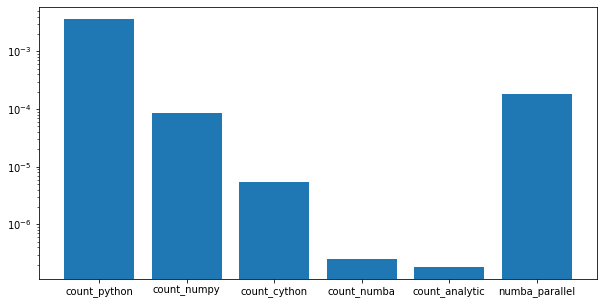

In [29]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,5))
values = list(timings.values())
labels = list(timings.keys())
x = range(len(labels))
ax.set_yscale('log')
plt.bar(x, values, align='center')
_xtcs = plt.xticks(x, labels)

#### Sum over squared numbers

In [30]:
from numba import jit

@jit(nopython=True)
def _count_squared_numba(n):
    j = 0
    for i in range(n):
        j += i*i
    return j

def count_squared_numba(n):
    return _count_squared_numba(n)

In [31]:
%%timeit
count_squared_numba(N)

251 ns ± 3.99 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


In [32]:
def count_squared_analytic(n):
    m = n - 1  # exclude n, to use Gauss' well-known formula below
    return m * (m + 1) * (2 * m + 1) // 6

In [33]:
%%timeit
count_squared_analytic(N)

326 ns ± 1.82 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


#### Does Numba preserve Python semantics?
* Python implements infinite precision integers!

In [34]:
M = 2**63 - 1

In [35]:
count_analytic(M)

279 ns ± 4.56 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


42535295865117307919086767873688862721

In [36]:
# integer overflow
count_numba(M)

279 ns ± 1.62 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


4611686018427387905

### Thank you!

### Questions?